In [ ]:
import torch
from snntorch import functional as SF

from thesis_code.datasets import get_SHD_dataloader
from thesis_code.networks import train, test, models
from thesis_code.plotting import plot_performance

c:\Users\emiel\Documents\Study\Thesis\Thesis-Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [ ]:
SHD_trainloader, input_dim, classes = get_SHD_dataloader(
    batch_size=128,
    time_window=10000,
    train=True,
    shuffle=True,
    re_download=False,
)

SHD_testloader, _, _ = get_SHD_dataloader(
    batch_size=128,
    time_window=10000,
    train=False,
    shuffle=True,
    re_download=False,
)

net = models.SimpleSRNN(
    n_in=input_dim,
    ns_hidden=[1000],
    n_out=len(classes),
    beta=0.9,
).to(device)

130864128it [00:26, 4875355.40it/s]                               


Extracting C:\Users\emiel\Documents\Study\Thesis\Thesis-Code\datasets\data\SHD\shd_train.h5.zip to C:\Users\emiel\Documents\Study\Thesis\Thesis-Code\datasets\data\SHD


38141952it [00:04, 8358897.08it/s]                               


Extracting C:\Users\emiel\Documents\Study\Thesis\Thesis-Code\datasets\data\SHD\shd_test.h5.zip to C:\Users\emiel\Documents\Study\Thesis\Thesis-Code\datasets\data\SHD


Epoch 0:   2%|▏         | 1/64 [00:02<03:06,  2.97s/it, acc=5.47%, loss=0.16]

Epoch 0, Iteration 0 — Loss: 0.16, Acc: 5.47%


Epoch 0:  41%|████      | 26/64 [01:16<01:49,  2.88s/it, acc=5.47%, loss=5.65]  

Epoch 0, Iteration 25 — Loss: 5.65, Acc: 5.47%


Epoch 0:  80%|███████▉  | 51/64 [02:31<00:39,  3.06s/it, acc=3.91%, loss=0.66] 

Epoch 0, Iteration 50 — Loss: 0.66, Acc: 3.91%


Epoch 0: 100%|██████████| 64/64 [03:10<00:00,  2.97s/it, acc=3.26%, loss=0.41] 


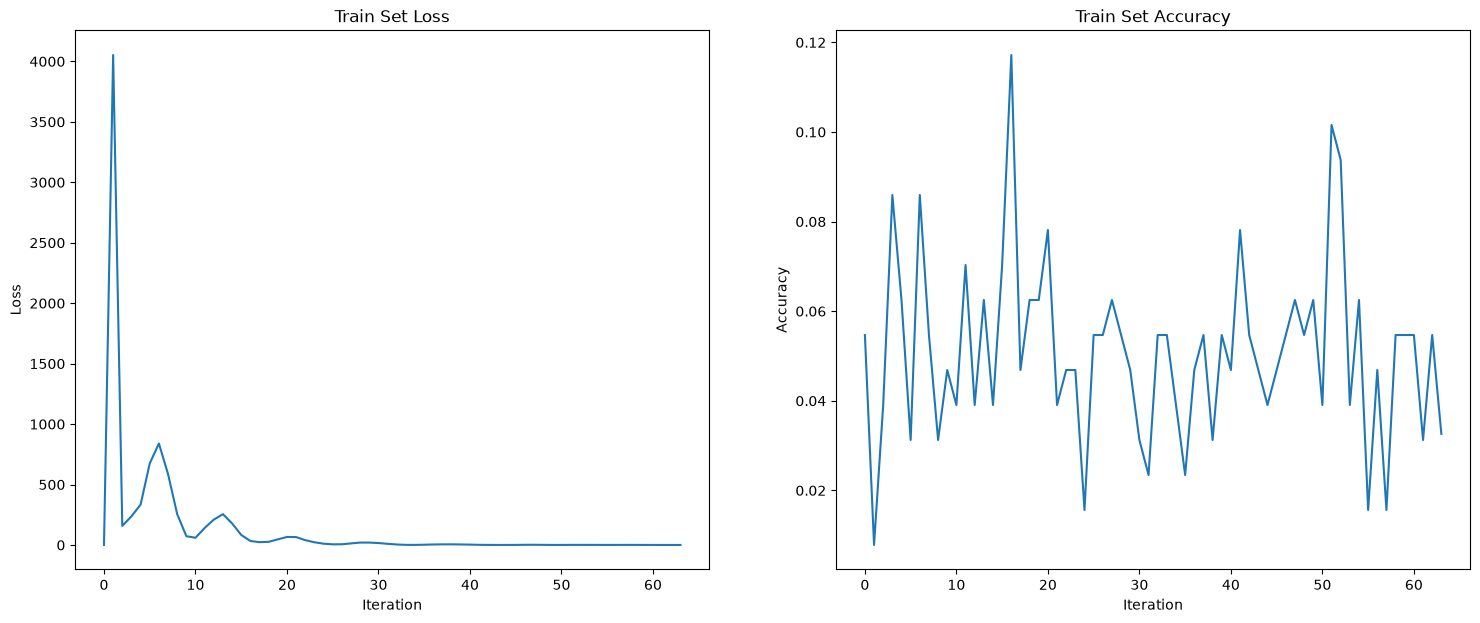

In [4]:
net, loss_hist, acc_hist = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    optimizer=torch.optim.Adam(net.parameters(), lr=2e-2, betas=(0.9, 0.999)),
    loss_fn=SF.mse_membrane_loss(on_target=1.05, off_target=0.2, time_var_targets=False),
    n_epochs=1,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)

In [5]:
accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy is: {accuracy}")

Test Accuracy is: 0.05079505300353357
